# Step 1. Import the Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats


# Step 2. Creating the Database

In [3]:
np.random.seed()        # used to stop generating random values continously

data = {
    'product_id':range(1,21),
    'product_name': [f'Product {i}' for i in range(1,21)],
    'category':np.random.choice(["Electronics", "Clothing","Home","Sports"], 20),
    "unit_sold": np.random.poisson(lam=20, size = 20),
    'sale_date': pd.date_range(start='2023-01-01', periods = 20, freq = "D")
}

sales_data = pd.DataFrame(data)

print("Sales Data: ")
print(sales_data)

Sales Data: 
    product_id product_name     category  unit_sold  sale_date
0            1    Product 1     Clothing         12 2023-01-01
1            2    Product 2     Clothing         19 2023-01-02
2            3    Product 3     Clothing         15 2023-01-03
3            4    Product 4         Home         22 2023-01-04
4            5    Product 5     Clothing         27 2023-01-05
5            6    Product 6  Electronics         16 2023-01-06
6            7    Product 7         Home         23 2023-01-07
7            8    Product 8     Clothing         19 2023-01-08
8            9    Product 9         Home         23 2023-01-09
9           10   Product 10     Clothing         16 2023-01-10
10          11   Product 11         Home         21 2023-01-11
11          12   Product 12         Home         15 2023-01-12
12          13   Product 13       Sports         23 2023-01-13
13          14   Product 14     Clothing         15 2023-01-14
14          15   Product 15         Home  

In [4]:
sales_data.to_csv('Sales_data.csv', index=False)

In [5]:
import os
os.getcwd()

'c:\\Users\\Akash\\Desktop\\FSDS\\Inferential Statistics'

# Step 3: Descriptive Statistics

In [6]:
print("Descriptive Statistics for Unit Sold:")

print(sales_data.describe())

print()

mean_sales = (sales_data['unit_sold'].mean())
print(mean_sales)
median_sales =(sales_data['unit_sold'].median())
print(median_sales)
mode_sales = (sales_data['unit_sold'].mode()[0])
print(mode_sales)
std_sales = (sales_data['unit_sold'].std())
print(std_sales)
print(sales_data['unit_sold'].var())

print()

category_stats = sales_data.groupby('category')['unit_sold'].agg(['sum','mean','std']).reset_index()
category_stats.columns = ['category', 'Total Units Sold', 'Avg Unit Sold','Std Dev of Unit Sold']

print("Statistical Analysis")
print(category_stats)

Descriptive Statistics for Unit Sold:
       product_id  unit_sold            sale_date
count    20.00000  20.000000                   20
mean     10.50000  19.900000  2023-01-10 12:00:00
min       1.00000  12.000000  2023-01-01 00:00:00
25%       5.75000  15.750000  2023-01-05 18:00:00
50%      10.50000  20.000000  2023-01-10 12:00:00
75%      15.25000  23.000000  2023-01-15 06:00:00
max      20.00000  31.000000  2023-01-20 00:00:00
std       5.91608   5.200202                  NaN

19.9
20.0
23
5.200202425209801
27.042105263157897

Statistical Analysis
      category  Total Units Sold  Avg Unit Sold  Std Dev of Unit Sold
0     Clothing               136      17.000000              4.750940
1  Electronics                68      22.666667              7.637626
2         Home               143      20.428571              3.457222
3       Sports                51      25.500000              3.535534


# Step 4. Inferential Statistics

In [7]:
confidence_level = 0.95
degrees_freedom =  len(sales_data['unit_sold'])-1
sample_mean = mean_sales
sample_standard_error = std_sales/np.sqrt(len(sales_data['unit_sold']))

# T-Score for confidence Interval

t_score = stats.t.ppf((1+ confidence_level)/2, degrees_freedom)
margin_of_error = t_score * sample_standard_error


confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print("\n Confidence Interval for the Mean of Units Sold:")
print(confidence_interval)


 Confidence Interval for the Mean of Units Sold:
(np.float64(17.466230348702005), np.float64(22.33376965129799))


In [8]:
confidence_level = 0.99
degrees_freedom =  len(sales_data['unit_sold'])-1
sample_mean = mean_sales
sample_standard_error = std_sales/np.sqrt(len(sales_data['unit_sold']))

# T-Score for confidence Interval

t_score = stats.t.ppf((1+ confidence_level)/2, degrees_freedom)
margin_of_error = t_score * sample_standard_error


confidence_interval = (sample_mean - margin_of_error, sample_mean + margin_of_error)
print("\n Confidence Interval for the Mean of Units Sold:")
print(confidence_interval)


 Confidence Interval for the Mean of Units Sold:
(np.float64(16.573303488845468), np.float64(23.22669651115453))


# Hypothesis Testing

In [ ]:
t_statistics, p_value = stats.ttest_1samp(sales_data['unit_sold'], 20)

print("Hypothesis Testing (t-test):")

print(f"T-Statistics : {t_statistics}, P-value:  {p_value}")

if p_value>0.05:
    print("Reject the Null Hypothesis")
else:
    print("Accept the Null Hypothesis")

Hypothesis Testing (t-test):
T-Statistics : -0.08599926674622123, P-value:  0.932366807210202
Reject the Null Hypothesis


# Step 5 -  Visualization

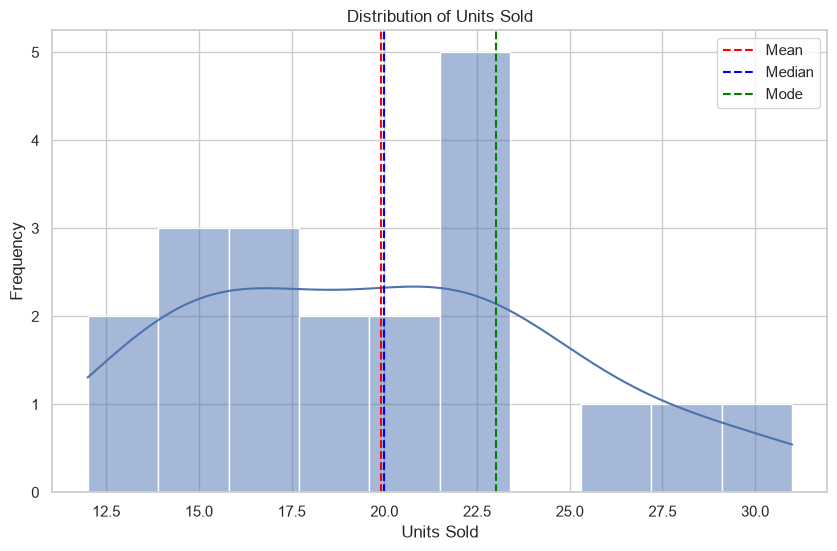

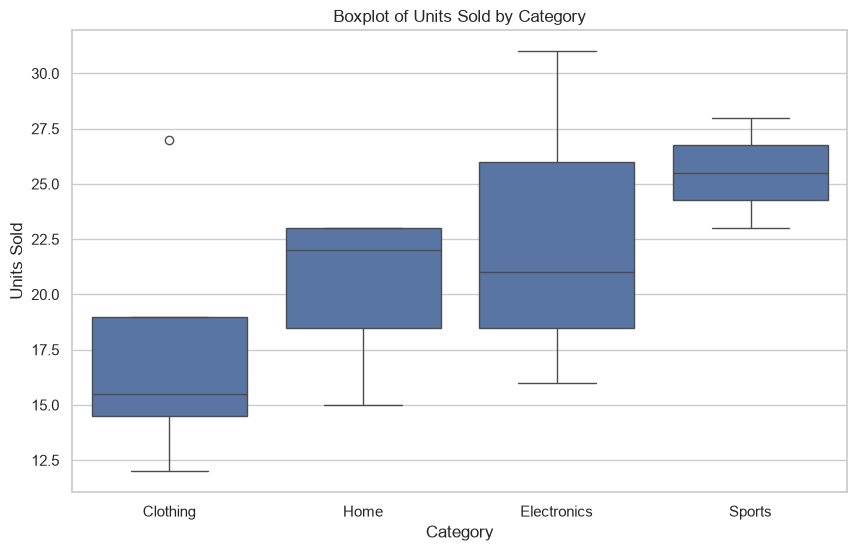

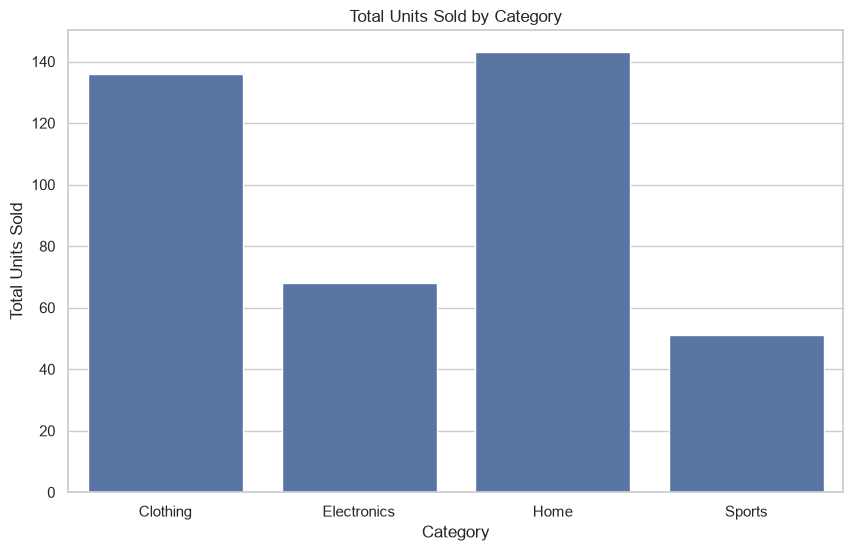

In [11]:
# Visualizations
sns.set(style="whitegrid")

# Plot distribution of units sold
plt.figure(figsize=(10, 6))
sns.histplot(sales_data['unit_sold'], bins=10, kde=True)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.axvline(mean_sales, color='red', linestyle='--', label='Mean')
plt.axvline(median_sales, color='blue', linestyle='--', label='Median')
plt.axvline(mode_sales, color='green', linestyle='--', label='Mode')
plt.legend()
plt.show()

# Boxplot for units sold by category
plt.figure(figsize=(10, 6))
sns.boxplot(x='category', y='unit_sold', data=sales_data)
plt.title('Boxplot of Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.show()

# Bar plot for total units sold by category
plt.figure(figsize=(10, 6))
sns.barplot(x='category', y='Total Units Sold', data=category_stats)
plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Units Sold')
plt.show()


In [12]:
sales_data.columns

Index(['product_id', 'product_name', 'category', 'unit_sold', 'sale_date'], dtype='str')